In [1]:
import math 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
np.random.seed(42)

In [2]:
def f(x):
    return 3*x**2 + 2*x + 7

xs = np.arange(-3, 3, 0.10)
xs


array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00,  1.10000000e+00,  1.20000000e+00,  1.30000000e+00,
        1.40000000e+00,  1.50000000e+00,  1.60000000e+00,  1.70000000e+00,
        1.80000000e+00,  1.90000000e+00,  2.00000000e+00,  2.10000000e+00,
        2.20000000e+00,  

In [3]:
ys = f(xs)
ys

array([28.  , 26.43, 24.92, 23.47, 22.08, 20.75, 19.48, 18.27, 17.12,
       16.03, 15.  , 14.03, 13.12, 12.27, 11.48, 10.75, 10.08,  9.47,
        8.92,  8.43,  8.  ,  7.63,  7.32,  7.07,  6.88,  6.75,  6.68,
        6.67,  6.72,  6.83,  7.  ,  7.23,  7.52,  7.87,  8.28,  8.75,
        9.28,  9.87, 10.52, 11.23, 12.  , 12.83, 13.72, 14.67, 15.68,
       16.75, 17.88, 19.07, 20.32, 21.63, 23.  , 24.43, 25.92, 27.47,
       29.08, 30.75, 32.48, 34.27, 36.12, 38.03])

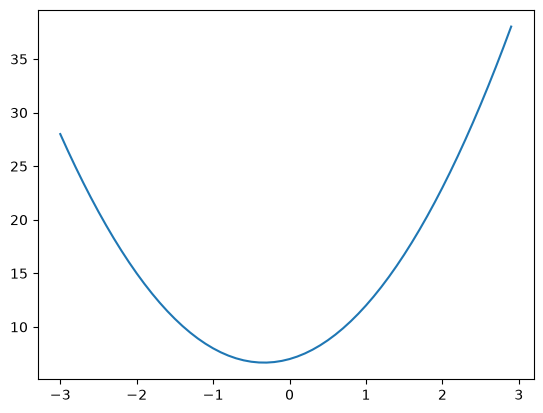

In [4]:
sns.lineplot(
    x = xs,
    y = ys
)

plt.show()

In [5]:
# Calculate the derivative at a point 
h = 0.0001
a = -0.3
dydx = (f(a + h) - f(a)) / h
dydx

0.200299999999487

In [6]:
# Multiple inputs

a = 5
b = 0.7
c = 12

d1 = a * b * c 

In [7]:
h = 0.00001
a += h 
d2 = a * b * c 
print(d1)
print(d2)

42.0
42.000083999999994


In [8]:
slope = (d2 - d1) / h
slope

8.399999999397778

In [25]:
class value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"value(data = {self.data:1f})"

    def __add__(self, other):
        out = value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = value(self.data * other.data, (self, other), '*')
        return out

In [26]:
a = value(3, label = 'a')
b = value(7, label = 'b')

In [39]:
c = a + b; c.label = 'c'
print(c)

value(data = 10.000000)


In [31]:
d = a * b + c 
d

value(data = 31.000000)

In [32]:
d._prev

{value(data = 10.000000), value(data = 21.000000)}

In [33]:
d._op

'+'

In [34]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

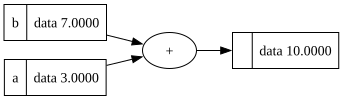

In [38]:
draw_dot(c)